In [93]:
import warnings

In [94]:
warnings.filterwarnings("ignore")

In [95]:
import pandas as pd

In [96]:
import numpy as np

In [97]:
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler

In [98]:
raw_iris = load_iris()
features = raw_iris.feature_names
X_raw = raw_iris.data
y_true = raw_iris.target

In [99]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)

In [100]:
iris_df = pd.DataFrame(data=X_scaled, columns=features)
iris_df['species_id'] = y_true
species_map = {i: name for i, name in enumerate(raw_iris.target_names)}
iris_df['species_name'] = iris_df['species_id'].map(species_map)


In [101]:
print("Standardized dataset dimensions:", X_scaled.shape)
print("\nFirst 3 rows of standardized dataset:")
print(iris_df.head(3))

Standardized dataset dimensions: (150, 4)

First 3 rows of standardized dataset:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0          -0.900681          1.019004          -1.340227         -1.315444   
1          -1.143017         -0.131979          -1.340227         -1.315444   
2          -1.385353          0.328414          -1.397064         -1.315444   

   species_id species_name  
0           0       setosa  
1           0       setosa  
2           0       setosa  


In [102]:
cov_matrix = np.cov(X_scaled.T)
print("Covariance Matrix:\n", cov_matrix)

Covariance Matrix:
 [[ 1.00671141 -0.11835884  0.87760447  0.82343066]
 [-0.11835884  1.00671141 -0.43131554 -0.36858315]
 [ 0.87760447 -0.43131554  1.00671141  0.96932762]
 [ 0.82343066 -0.36858315  0.96932762  1.00671141]]


In [103]:
eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)
print("\nEigenvalues (Variance components):\n", eigenvalues)
print("\nEigenvectors (Principal Axes):\n", eigenvectors)



Eigenvalues (Variance components):
 [2.93808505 0.9201649  0.14774182 0.02085386]

Eigenvectors (Principal Axes):
 [[ 0.52106591 -0.37741762 -0.71956635  0.26128628]
 [-0.26934744 -0.92329566  0.24438178 -0.12350962]
 [ 0.5804131  -0.02449161  0.14212637 -0.80144925]
 [ 0.56485654 -0.06694199  0.63427274  0.52359713]]


In [104]:
from sklearn.decomposition import PCA

In [105]:
pca_model = PCA(n_components=2, random_state=42)
X_pca = pca_model.fit_transform(X_scaled)

In [106]:
pca_df = pd.DataFrame(data=X_pca, columns=['PC_1', 'PC2'])
pca_df['species_name'] = iris_df['species_name']

In [107]:
print("Transformed PCA space dimensions:", X_pca.shape)
print("\nFirst 3 projected coordinates:")
print(pca_df.head(3))


Transformed PCA space dimensions: (150, 2)

First 3 projected coordinates:
       PC_1       PC2 species_name
0 -2.264703  0.480027       setosa
1 -2.080961 -0.674134       setosa
2 -2.364229 -0.341908       setosa


In [108]:
import matplotlib.pyplot as plt
import seaborn as sns

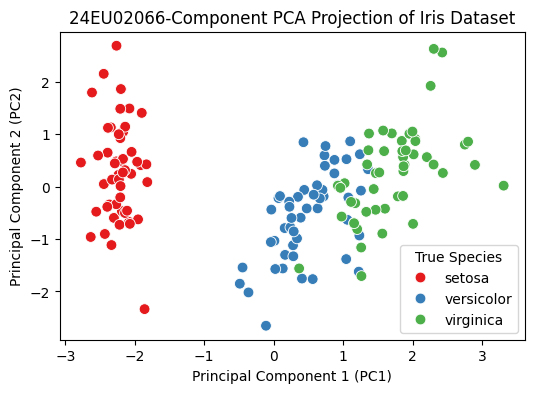

In [109]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6, 4))
sns.scatterplot(data=pca_df, x='PC_1', y='PC2', hue='species_name', palette='Set1', s=60)
plt.title("24EU02066-Component PCA Projection of Iris Dataset")
plt.xlabel("Principal Component 1 (PC1)")
plt.ylabel("Principal Component 2 (PC2)")
plt.legend(title='True Species')
plt.show()

In [110]:
explained_variance = pca_model.explained_variance_ratio_
cumulative_variance = np.sum(explained_variance)

In [111]:
print("Explained Variance per Component:")
for i, var in enumerate(explained_variance):
    print(f"  PC{i+1}: {var*100:.2f}%")

Explained Variance per Component:
  PC1: 72.96%
  PC2: 22.85%


In [112]:
print(f"\nTotal Cumulative Variance Retained by 2 Components: {cumulative_variance*100:.2f}%")


Total Cumulative Variance Retained by 2 Components: 95.81%


In [113]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [114]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [115]:
iris = load_iris()

In [116]:
X = iris.data
y = iris.target
feature_names = iris.feature_names
target_names = iris.target_names

In [117]:
print("Dataset Shape:", X.shape)
print("Features:", feature_names)
print("Classes:", target_names)

Dataset Shape: (150, 4)
Features: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Classes: ['setosa' 'versicolor' 'virginica']


In [118]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)


In [119]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [120]:

print("\n========================================")
print("CLASSIFICATION WITHOUT PCA")
print("========================================")


CLASSIFICATION WITHOUT PCA


In [121]:
model_without_pca = LogisticRegression(
    random_state=42,
    max_iter=1000
)

In [122]:
model_without_pca.fit(
    X_train_scaled,
    y_train
)


LogisticRegression(max_iter=1000, random_state=42)

In [123]:
y_pred_without_pca = model_without_pca.predict(
    X_test_scaled
)


In [124]:
accuracy_without_pca = accuracy_score(
    y_test,
    y_pred_without_pca
)


In [125]:
print("Accuracy without PCA:",
      accuracy_without_pca)

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred_without_pca,
        target_names=target_names
    )
)



Accuracy without PCA: 0.9333333333333333

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      0.90      0.90        10
   virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30



In [126]:

print("\n========================================")
print("CLASSIFICATION WITH PCA")
print("========================================")


CLASSIFICATION WITH PCA


In [127]:
pca = PCA(
    n_components=2
)


In [128]:
X_train_pca = pca.fit_transform(
    X_train_scaled
)

In [129]:
X_test_pca = pca.transform(
    X_test_scaled
)

In [130]:
print("Explained Variance Ratio:",
      pca.explained_variance_ratio_)

print("Total Explained Variance:",
      pca.explained_variance_ratio_.sum())

Explained Variance Ratio: [0.72677234 0.23066667]
Total Explained Variance: 0.9574390106545363


In [131]:
model_with_pca = LogisticRegression(
    random_state=42,
    max_iter=1000
)


In [132]:
model_with_pca.fit(
    X_train_pca,
    y_train
)


LogisticRegression(max_iter=1000, random_state=42)

In [133]:
y_pred_with_pca = model_with_pca.predict(
    X_test_pca
)


In [134]:
accuracy_with_pca = accuracy_score(
    y_test,
    y_pred_with_pca
)


In [135]:
print("Accuracy with PCA:",
      accuracy_with_pca)

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred_with_pca,
        target_names=target_names
    )
)

Accuracy with PCA: 0.9

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.82      0.90      0.86        10
   virginica       0.89      0.80      0.84        10

    accuracy                           0.90        30
   macro avg       0.90      0.90      0.90        30
weighted avg       0.90      0.90      0.90        30



In [136]:
print("\n========================================")
print("COMPARISON")
print("========================================")


COMPARISON


In [137]:
comparison = pd.DataFrame({
    "Method": [
        "Without PCA",
        "With PCA"
    ],
    "Number of Features": [
        X_train_scaled.shape[1],
        X_train_pca.shape[1]
    ],
    "Accuracy": [
        accuracy_without_pca,
        accuracy_with_pca
    ]
})

print(comparison)

        Method  Number of Features  Accuracy
0  Without PCA                   4  0.933333
1     With PCA                   2  0.900000


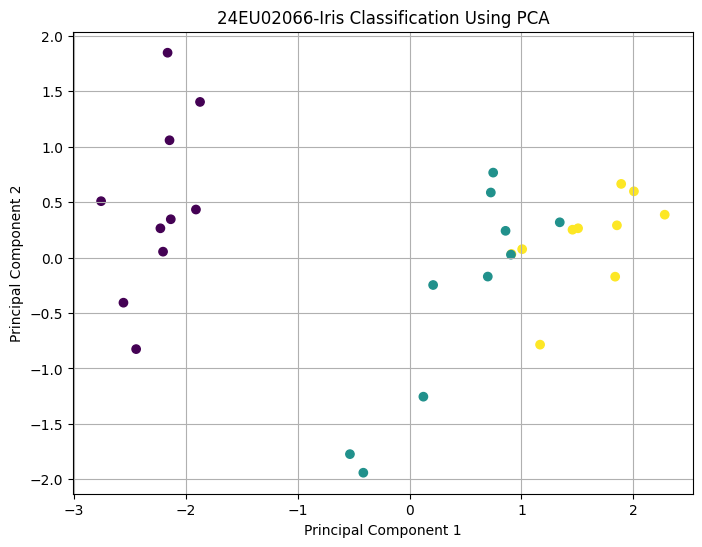

In [138]:
plt.figure(figsize=(8, 6))

plt.scatter(
    X_test_pca[:, 0],
    X_test_pca[:, 1],
    c=y_test
)
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("24EU02066-Iris Classification Using PCA")
plt.grid()

plt.show()

In [139]:
import warnings
warnings.filterwarnings("ignore")

In [140]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

In [141]:
wcss = []
k_range = range(1, 11)

In [142]:
for k in k_range:
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

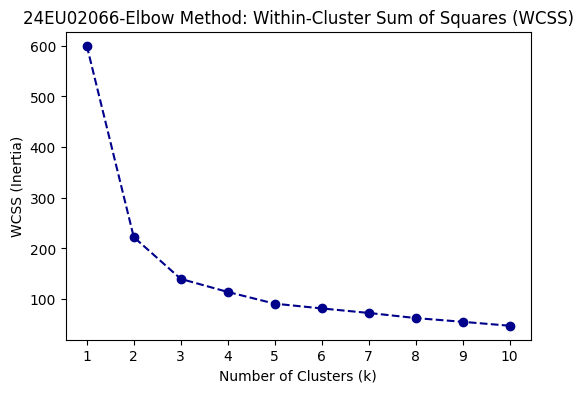

In [143]:
plt.figure(figsize=(6, 4))
plt.plot(k_range, wcss, marker='o', linestyle='--', color='darkblue')
plt.title("24EU02066-Elbow Method: Within-Cluster Sum of Squares (WCSS)")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("WCSS (Inertia)")
plt.xticks(k_range)
plt.show()

In [144]:
from sklearn.metrics import silhouette_score

In [145]:
silhouette_scores = []
k_eval = range(2, 6)

In [146]:
for k in k_eval:
    kmeans_temp = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    labels_temp = kmeans_temp.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels_temp)
    silhouette_scores.append(score)

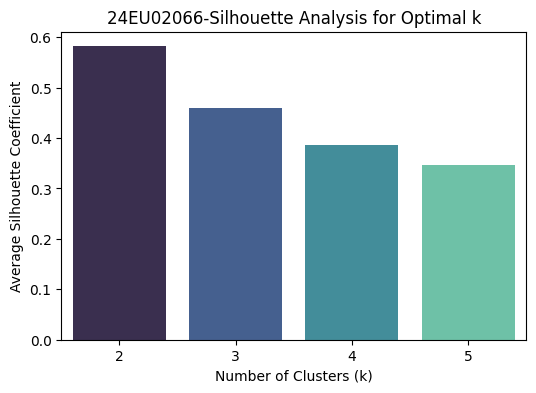

In [147]:
plt.figure(figsize=(6, 4))
sns.barplot(x=list(k_eval), y=silhouette_scores, palette='mako')
plt.title("24EU02066-Silhouette Analysis for Optimal k")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Average Silhouette Coefficient")
plt.show()

In [148]:
best_k = k_eval[np.argmax(silhouette_scores)]
print(f"k = {best_k} yielded the highest silhouette coefficient ({max(silhouette_scores):.4f}).")

k = 2 yielded the highest silhouette coefficient (0.5818).


In [149]:
kmeans_raw = KMeans(n_clusters=3, init='k-means++', random_state=42, n_init=10)
kmeans_raw_labels = kmeans_raw.fit_predict(X_scaled)


In [150]:
iris_df['cluster_raw'] = kmeans_raw_labels
print("K-Means clustering complete. First 5 sample allocations:")
print(iris_df[['species_name', 'cluster_raw']].head(5))

K-Means clustering complete. First 5 sample allocations:
  species_name  cluster_raw
0       setosa            1
1       setosa            1
2       setosa            1
3       setosa            1
4       setosa            1


In [151]:
raw_centroids_scaled = kmeans_raw.cluster_centers_

In [152]:
raw_centroids_physical = scaler.inverse_transform(raw_centroids_scaled)

In [153]:
centroids_df = pd.DataFrame(data=raw_centroids_physical, columns=features)
centroids_df.index = [f"Cluster_{i}" for i in range(3)]

In [154]:
print("--- Estimated Cluster Centroids (Original Physical Units - cm) ---")
print(centroids_df)


--- Estimated Cluster Centroids (Original Physical Units - cm) ---
           sepal length (cm)  sepal width (cm)  petal length (cm)  \
Cluster_0           5.799612          2.653772           4.382414   
Cluster_1           4.992043          3.429444           1.471740   
Cluster_2           6.792945          3.087827           5.524364   

           petal width (cm)  
Cluster_0          1.418814  
Cluster_1          0.251935  
Cluster_2          1.977790  


In [155]:
plt.figure(figsize=(6, 4))

<Figure size 600x400 with 0 Axes>

<Figure size 600x400 with 0 Axes>

In [156]:
raw_data = scaler.inverse_transform(X_scaled)

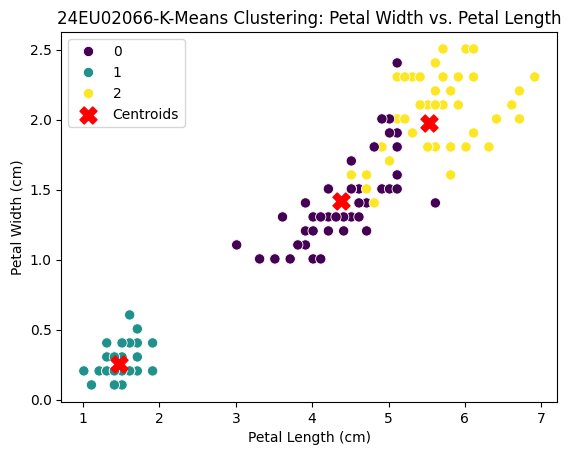

In [157]:
sns.scatterplot(x=raw_data[:, 2], y=raw_data[:, 3], hue=kmeans_raw_labels, palette='viridis', s=55, legend='full')
plt.scatter(
    raw_centroids_physical[:, 2],
    raw_centroids_physical[:, 3],
    color='red',
    marker='X',
    s=150,
    label='Centroids'
)

plt.title("24EU02066-K-Means Clustering: Petal Width vs. Petal Length")
plt.xlabel("Petal Length (cm)")
plt.ylabel("Petal Width (cm)")
plt.legend()
plt.show()


In [158]:
import warnings
warnings.filterwarnings("ignore")


In [159]:

from sklearn.cluster import KMeans

In [160]:
kmeans_pca = KMeans(n_clusters=3, init='k-means++', random_state=42, n_init=10)
kmeans_pca_labels = kmeans_pca.fit_predict(X_pca)

In [161]:

iris_df['cluster_pca'] = kmeans_pca_labels
print("PCA space K-Means clustering completed successfully.")


PCA space K-Means clustering completed successfully.


In [162]:
from sklearn.metrics import silhouette_score, calinski_harabasz_score, adjusted_rand_score, normalized_mutual_info_score

In [163]:

sil_raw = silhouette_score(X_scaled, kmeans_raw_labels)
ch_raw = calinski_harabasz_score(X_scaled, kmeans_raw_labels)
ari_raw = adjusted_rand_score(y_true, kmeans_raw_labels)
nmi_raw = normalized_mutual_info_score(y_true, kmeans_raw_labels)

In [164]:

sil_pca = silhouette_score(X_pca, kmeans_pca_labels)
ch_pca = calinski_harabasz_score(X_pca, kmeans_pca_labels)
ari_pca = adjusted_rand_score(y_true, kmeans_pca_labels)
nmi_pca = normalized_mutual_info_score(y_true, kmeans_pca_labels)

In [165]:

print("--- Internal Validation (Unsupervised Quality Metrics) ---")
print(f"Raw 4D Feature Space  -> Silhouette Score: {sil_raw:.4f} | Calinski-Harabasz: {ch_raw:.2f}")
print(f"PCA 2D Reduced Space -> Silhouette Score: {sil_pca:.4f} | Calinski-Harabasz: {ch_pca:.2f}")


--- Internal Validation (Unsupervised Quality Metrics) ---
Raw 4D Feature Space  -> Silhouette Score: 0.4599 | Calinski-Harabasz: 241.90
PCA 2D Reduced Space -> Silhouette Score: 0.5092 | Calinski-Harabasz: 293.86


In [166]:
import matplotlib.pyplot as plt
import seaborn as sns


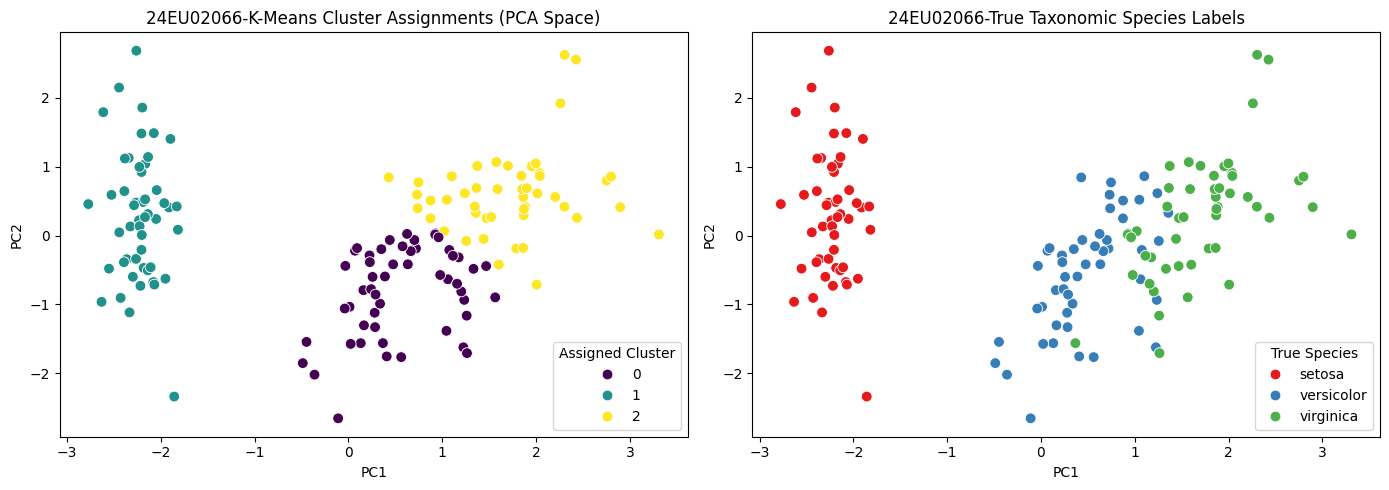

In [167]:

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.scatterplot(
    data=pca_df, x='PC_1', y='PC2', hue=kmeans_pca_labels,
    palette='viridis', s=60, ax=axes[0]
)
axes[0].set_title("24EU02066-K-Means Cluster Assignments (PCA Space)")
axes[0].set_xlabel("PC1")
axes[0].set_ylabel("PC2")
axes[0].legend(title='Assigned Cluster')

# Plot 2: PCA Coordinates colored by true species labels
sns.scatterplot(
    data=pca_df, x='PC_1', y='PC2', hue='species_name',
    palette='Set1', s=60, ax=axes[1]
)
axes[1].set_title("24EU02066-True Taxonomic Species Labels")
axes[1].set_xlabel("PC1")
axes[1].set_ylabel("PC2")
axes[1].legend(title='True Species')

plt.tight_layout()
plt.show()

In [168]:
comparison_metrics = pd.DataFrame(
    data=[
        [sil_raw, ch_raw, ari_raw, nmi_raw],
        [sil_pca, ch_pca, ari_pca, nmi_pca]
    ],
    columns=['Silhouette_Score', 'Calinski_Harabasz', 'Adjusted_Rand_Index', 'Normalized_Mutual_Info'],
    index=['Standardized Raw Space (4D)', 'PCA Reduced Space (2D)']
)

print("--- Clustering Performance Summary: Raw vs. PCA ---")
print(comparison_metrics.round(4))


--- Clustering Performance Summary: Raw vs. PCA ---
                             Silhouette_Score  Calinski_Harabasz  \
Standardized Raw Space (4D)            0.4599           241.9044   
PCA Reduced Space (2D)                 0.5092           293.8565   

                             Adjusted_Rand_Index  Normalized_Mutual_Info  
Standardized Raw Space (4D)               0.6201                  0.6595  
PCA Reduced Space (2D)                    0.6201                  0.6595  
